Loading graph: baoding_clear.graphml
Raw directed edge rows: 137072
Edge columns:
['u', 'v', 'key', 'length', 'segment_id', 'osmid', 'oneway', 'reversed', 'geometry', 'name', 'shield', 'EN_Class', 'CN_Class', 'district', 'city', 'province', 'Shape_Leng', 'parent_source_id', 'ref', 'highway', 'road_class_en', 'road_class_cn']
Using non-reversed edges only: 68666
Candidate class column: highway, non-empty share: 0.160

Using road class column: highway

Road type distribution:


,road_class_clean,edge_count,total_length_m,mean_length_m,edge_share,length_share
0,Unknown / missing,57673,4.534475e+06,78.623878,0.839906,0.892394
1,levelFourRoad,6464,3.123677e+05,48.324219,0.094137,0.061475
2,levelThreeRoad,2635,1.414844e+05,53.694261,0.038374,0.027844
3,secondaryRoad,1172,5.257222e+04,44.856847,0.017068,0.010346
4,nationalRoad,354,2.080109e+04,58.760135,0.005155,0.004094
5,provincialRoad,339,1.920431e+04,56.649897,0.004937,0.003779
6,overPass,29,3.434964e+02,11.844703,0.000422,0.000068


Saved distribution table: road_type_diagnostics\road_type_distribution.csv


C:\Users\Kwk10\AppData\Local\Temp\ipykernel_40472\3820919052.py:206: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(plot_order), 1))


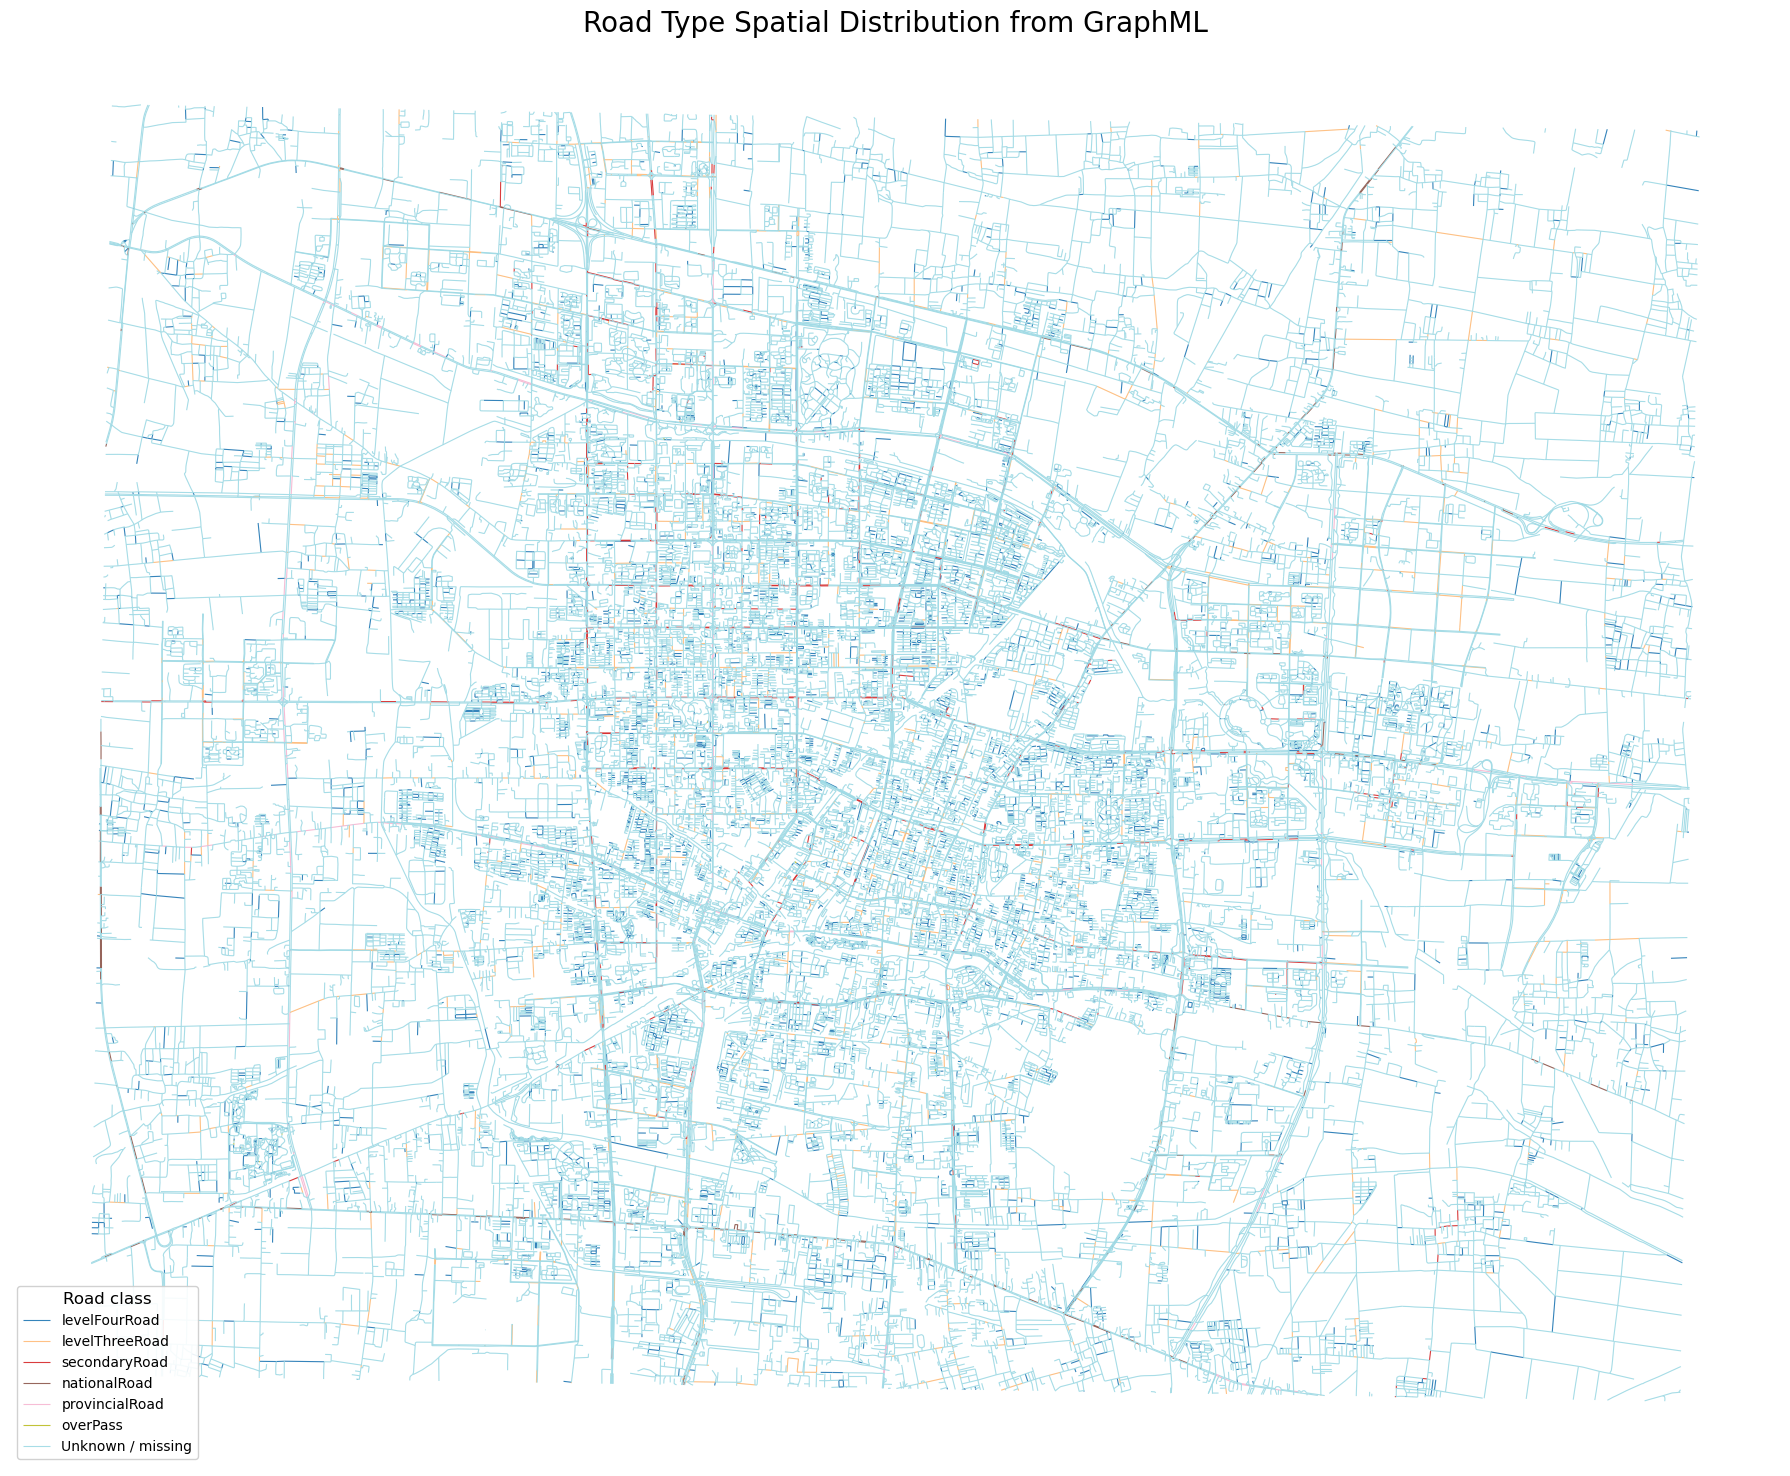

Saved road type map: road_type_diagnostics\road_type_spatial_distribution.png


In [1]:
# =========================================================
# Inspect road class distribution in GraphML
# and map spatial distribution
# Python 3.8 compatible
# =========================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox


# -----------------------------
# Config
# -----------------------------
try:
    GRAPH_PATH = GRAPH_FILE
except NameError:
    GRAPH_PATH = Path("baoding_clear.graphml")

GRAPH_PATH = Path(GRAPH_PATH)

OUT_DIR = Path("./road_type_diagnostics")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_COUNT_CSV = OUT_DIR / "road_type_distribution.csv"
OUT_MAP_PNG = OUT_DIR / "road_type_spatial_distribution.png"

# candidate road class columns inside graphml edge attributes
ROAD_CLASS_CANDIDATES = [
    "highway",
    "EN_Class",
    "CN_Class",
    "road_class_en",
    "road_class_cn",
    "fclass",
    "type",
    "class",
]

TOP_N_CLASSES = 12
OTHER_LABEL = "Other / rare"
UNKNOWN_LABEL = "Unknown / missing"

FIGSIZE = (18, 18)
BASE_LW = 0.2
CLASS_LW = 0.8
DPI = 300


# -----------------------------
# Helpers
# -----------------------------
def normalize_graphml_text(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s in {"", "nan", "None", "<NA>", "[]"}:
        return ""
    return s


def normalize_road_class(x):
    """
    GraphML may store list-like values as strings.
    Keep the first meaningful class for plotting.
    """
    s = normalize_graphml_text(x)

    if s == "":
        return UNKNOWN_LABEL

    # common list-like strings from OSMnx or graphml
    # examples: "['primary', 'secondary']", "primary;secondary"
    s = s.replace("[", "").replace("]", "")
    s = s.replace("'", "").replace('"', "")
    s = s.strip()

    if ";" in s:
        s = s.split(";")[0].strip()
    elif "," in s:
        s = s.split(",")[0].strip()

    if s == "":
        return UNKNOWN_LABEL

    return s


def parse_bool_like(x):
    s = normalize_graphml_text(x).lower()
    return s in {"true", "1", "yes", "y"}


def find_road_class_column(gdf_edges):
    for c in ROAD_CLASS_CANDIDATES:
        if c in gdf_edges.columns:
            vals = gdf_edges[c].apply(normalize_graphml_text)
            nonempty_share = float((vals != "").mean())
            print("Candidate class column: %s, non-empty share: %.3f" % (c, nonempty_share))
            if nonempty_share > 0:
                return c
    return None


# -----------------------------
# Load graph and edges
# -----------------------------
if not GRAPH_PATH.exists():
    raise FileNotFoundError("GraphML not found: %s" % GRAPH_PATH)

print("Loading graph:", GRAPH_PATH)
G = ox.load_graphml(str(GRAPH_PATH))

gdf_edges = ox.graph_to_gdfs(G, nodes=False).reset_index()
print("Raw directed edge rows:", len(gdf_edges))
print("Edge columns:")
print(list(gdf_edges.columns))

# Avoid double-counting reverse edges if the graph was exported as bidirectional.
if "reversed" in gdf_edges.columns:
    reversed_mask = gdf_edges["reversed"].apply(parse_bool_like)
    gdf_edges_oneway = gdf_edges[~reversed_mask].copy()
    print("Using non-reversed edges only:", len(gdf_edges_oneway))
else:
    # fallback: use undirected graph if no reversed flag exists
    try:
        G_undir = ox.convert.to_undirected(G)
        gdf_edges_oneway = ox.graph_to_gdfs(G_undir, nodes=False).reset_index()
        print("No reversed column. Using undirected graph edges:", len(gdf_edges_oneway))
    except Exception:
        gdf_edges_oneway = gdf_edges.copy()
        print("No reversed column and undirected conversion failed. Using all edges.")

if "length" not in gdf_edges_oneway.columns:
    gdf_edges_oneway["length"] = gdf_edges_oneway.geometry.length

gdf_edges_oneway["length"] = pd.to_numeric(gdf_edges_oneway["length"], errors="coerce")
gdf_edges_oneway["length"] = gdf_edges_oneway["length"].fillna(gdf_edges_oneway.geometry.length)


# -----------------------------
# Detect and summarize road class
# -----------------------------
class_col = find_road_class_column(gdf_edges_oneway)

if class_col is None:
    print("\nNo usable road class column found.")
    print("This often happens if the graph was built after unary_union or noding, because those operations drop original road attributes.")
    print("You can still draw the base road network, but road-type coloring is unavailable.")
    gdf_edges_oneway["road_class_clean"] = UNKNOWN_LABEL
else:
    print("\nUsing road class column:", class_col)
    gdf_edges_oneway["road_class_clean"] = gdf_edges_oneway[class_col].apply(normalize_road_class)

dist = (
    gdf_edges_oneway
    .groupby("road_class_clean", dropna=False)
    .agg(
        edge_count=("geometry", "size"),
        total_length_m=("length", "sum"),
        mean_length_m=("length", "mean"),
    )
    .reset_index()
)

dist["edge_share"] = dist["edge_count"] / dist["edge_count"].sum()
dist["length_share"] = dist["total_length_m"] / dist["total_length_m"].sum()
dist = dist.sort_values("total_length_m", ascending=False).reset_index(drop=True)

dist.to_csv(OUT_COUNT_CSV, index=False)
print("\nRoad type distribution:")
display(dist)
print("Saved distribution table:", OUT_COUNT_CSV)


# -----------------------------
# Prepare top classes for map
# -----------------------------
top_classes = (
    dist[dist["road_class_clean"] != UNKNOWN_LABEL]
    .head(TOP_N_CLASSES)["road_class_clean"]
    .tolist()
)

def road_class_for_plot(x):
    if x == UNKNOWN_LABEL:
        return UNKNOWN_LABEL
    if x in top_classes:
        return x
    return OTHER_LABEL

gdf_edges_oneway["road_class_plot"] = gdf_edges_oneway["road_class_clean"].apply(road_class_for_plot)

plot_order = top_classes[:]
if (gdf_edges_oneway["road_class_plot"] == OTHER_LABEL).any():
    plot_order.append(OTHER_LABEL)
if (gdf_edges_oneway["road_class_plot"] == UNKNOWN_LABEL).any():
    plot_order.append(UNKNOWN_LABEL)

# stable colors from matplotlib tab20
cmap = plt.cm.get_cmap("tab20", max(len(plot_order), 1))
color_map = {}
for i, cls in enumerate(plot_order):
    color_map[cls] = cmap(i)

gdf_edges_oneway["plot_color"] = gdf_edges_oneway["road_class_plot"].map(color_map)


# -----------------------------
# Plot map
# -----------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

# background
gdf_edges_oneway.plot(
    ax=ax,
    color="#dddddd",
    linewidth=BASE_LW,
    alpha=0.45,
    zorder=1,
)

# plot class by class for cleaner legend
for cls in plot_order:
    sub = gdf_edges_oneway[gdf_edges_oneway["road_class_plot"] == cls]
    if len(sub) == 0:
        continue
    sub.plot(
        ax=ax,
        color=color_map[cls],
        linewidth=CLASS_LW,
        alpha=0.90,
        label=cls,
        zorder=2,
    )

ax.set_title("Road Type Spatial Distribution from GraphML", fontsize=20)
ax.axis("off")

leg = ax.legend(
    title="Road class",
    loc="lower left",
    frameon=True,
    fontsize=10,
    title_fontsize=12,
)
leg.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.savefig(OUT_MAP_PNG, dpi=DPI, bbox_inches="tight")
plt.show()

print("Saved road type map:", OUT_MAP_PNG)